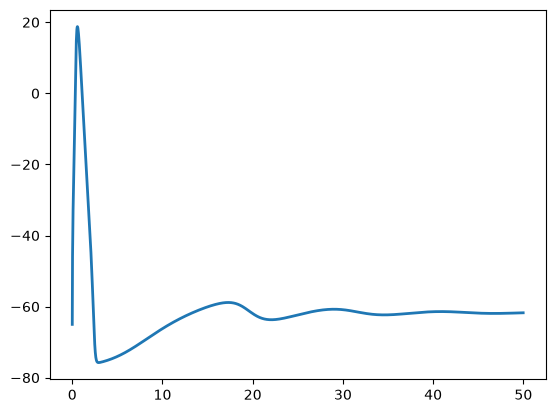

In [3]:
from logic.ode_solver_euler import euler_method
import matplotlib.pyplot as plt
import numpy as np

x = np.array([0.6, 0.5, 0.4])
tuple_of_constants = (1, 36, 120, 0.3, -77, 50, -54.387)

t_a = 0
t_b = 50
dt = 0.03
V_0 = -65
I = 5
v = euler_method(x, t_a, t_b, dt, V_0, I, tuple_of_constants )
tpoints = np.arange(0, 50, dt)
plt.plot(tpoints,v, linewidth=2)

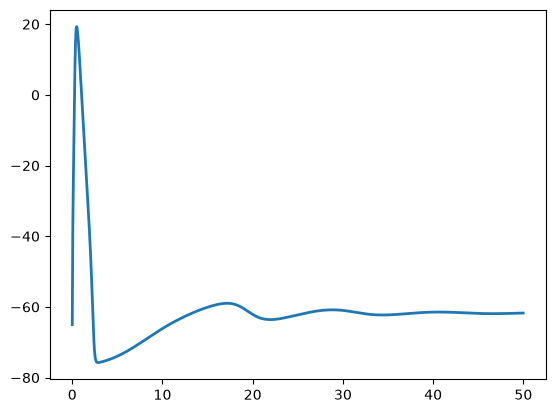

In [2]:
from logic.ode_solver_runge_kutta import runge_kutta_method
import matplotlib.pyplot as plt
import numpy as np

x = np.array([0.6, 0.5, 0.4])
tuple_of_constants = (1, 36, 120, 0.3, -77, 50, -54.387)


v = euler_method(x, t_a, t_b, dt, V_0, I, tuple_of_constants )
plt.plot(tpoints,v, linewidth=2)

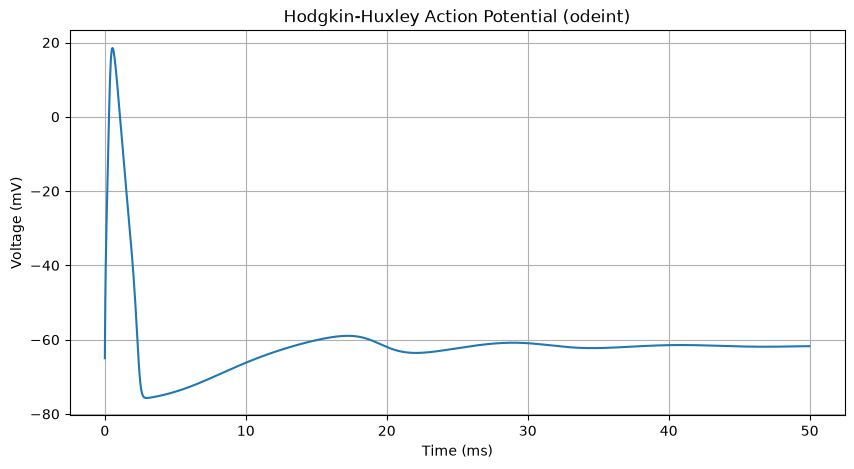

In [5]:
import scipy.integrate as spi
from logic.ode_solver_odeint import hh_system
state_0 = [-65, 0.6, 0.5, 0.4]

# --- Time array and injected current ---
   # 0 to 50 ms, fine resolution
I = 5                        # constant injected current [uA/cm^2]

# --- Solve ---
solution = spi.odeint(hh_system, state_0, t, args=(I,tuple_of_constants) )

V_t = solution[:, 0]
n_t = solution[:, 1]
m_t = solution[:, 2]
h_t = solution[:, 3]

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(tpoints, V_t)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Hodgkin-Huxley Action Potential (odeint)')
plt.grid(True)
plt.show()

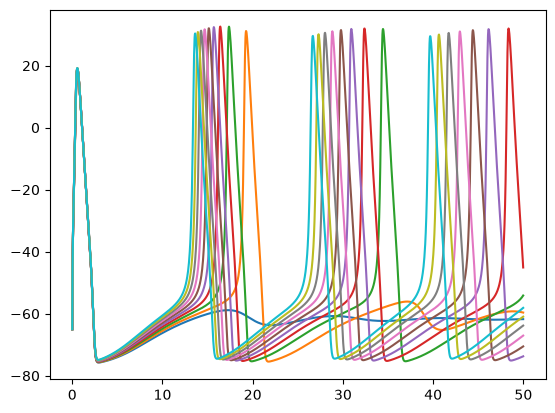

In [6]:
current_values = np.arange(5,15,1)
list_of_arrays = []
for i in current_values:
    temp = euler_method(x, t_a, t_b, dt, V_0, i, tuple_of_constants)
    list_of_arrays.append(temp)

voltage_matrix = np.array(list_of_arrays)
plt.plot(tpoints, voltage_matrix.T)
plt.show()
